# Model Training and Evaluation

## Overview

This notebook focuses on developing and evaluating machine learning models for predicting customer churn. The processed dataset is divided into training and testing sets, multiple classification algorithms are trained, and their performance is evaluated using standard classification metrics.

## Activities Performed

- Load the processed dataset
- Split the dataset into training and testing sets
- Train multiple machine learning models
- Evaluate model performance
- Compare model performance
- Select the best-performing model
- Save the trained model

**Assignment Mapping**

This notebook satisfies **Sub-Objective 2 – Design and Development of a Machine Learning Pipeline**, including:

- Model preparation
- Model training
- Model evaluation
- Model comparison

In [17]:
import os
import joblib

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [18]:
df = pd.read_csv("../data/processed/customer_churn_processed.csv")

print("Processed dataset loaded successfully.")
print(f"Dataset Shape: {df.shape}")

df.head()

Processed dataset loaded successfully.
Dataset Shape: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,-1.277445,-1.160323,-0.994242,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,0.066327,-0.259629,-0.173244,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,-1.236724,-0.362660,-0.959674,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,0.514251,-0.746535,-0.194766,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,-1.236724,0.197365,-0.940470,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


## 2. Train-Test Split

The processed dataset is divided into training and testing sets using a 70:30 ratio. The target variable is customer churn, while the remaining features are used for model training.

Assignment Mapping: Sub-Objective 2.2 – Model Training.

In [19]:
# Define features and target variable
X = df.drop(columns=["Churn_Yes"])
y = df["Churn_Yes"]

# Split dataset into training and testing sets (70:30)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train-test split completed successfully.")

print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")
print(f"Training Labels   : {y_train.shape}")
print(f"Testing Labels    : {y_test.shape}")

Train-test split completed successfully.
Training Features : (4930, 30)
Testing Features  : (2113, 30)
Training Labels   : (4930,)
Testing Labels    : (2113,)


In [20]:
split_summary = pd.DataFrame({
    "Dataset": [
        "Training Features",
        "Testing Features",
        "Training Labels",
        "Testing Labels"
    ],
    "Rows": [
        X_train.shape[0],
        X_test.shape[0],
        y_train.shape[0],
        y_test.shape[0]
    ],
    "Columns": [
        X_train.shape[1],
        X_test.shape[1],
        1,
        1
    ]
})

split_summary.to_csv(
    "../reports/train_test_split_summary.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.axis("off")

table = ax.table(
    cellText=split_summary.values,
    colLabels=split_summary.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

plt.savefig(
    "../reports/train_test_split_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Train-test split artifacts saved successfully.")

split_summary

Train-test split artifacts saved successfully.


,Dataset,Rows,Columns
0,Training Features,4930,30
1,Testing Features,2113,30
2,Training Labels,4930,1
3,Testing Labels,2113,1


## 3. Model Evaluation Function

A reusable evaluation function is created to train models, generate predictions, calculate classification metrics, and save confusion matrix visualizations.

Assignment Mapping:
- Sub-Objective 2.1 – Model Preparation
- Sub-Objective 2.3 – Model Evaluation

In [21]:
model_results = []

def train_and_evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()

    cm_path = f"../reports/confusion_matrix_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(cm_path, dpi=300)
    plt.show()

    report = classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"],
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).transpose()

    report_path = f"../reports/classification_report_{model_name.lower().replace(' ', '_')}.csv"
    report_df.to_csv(report_path)

    print(f"{model_name} training and evaluation completed.")
    print("Confusion Matrix PNG:", cm_path)
    print("Classification Report CSV:", report_path)

    return model

## 4. Logistic Regression

Logistic Regression is used as a baseline classification model for customer churn prediction.

Assignment Mapping:
- Sub-Objective 2.1 – Model Preparation
- Sub-Objective 2.2 – Model Training

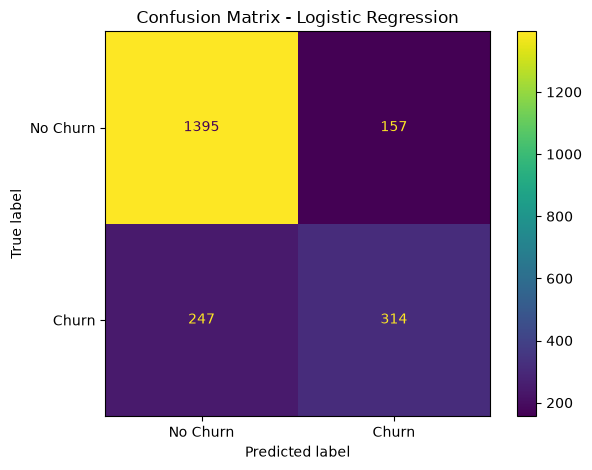

Logistic Regression training and evaluation completed.
Confusion Matrix PNG: ../reports/confusion_matrix_logistic_regression.png
Classification Report CSV: ../reports/classification_report_logistic_regression.csv


In [22]:
logistic_regression_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_regression_model = train_and_evaluate_model(
    model_name="Logistic Regression",
    model=logistic_regression_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

## 5. Random Forest

Random Forest is an ensemble-based classification algorithm that combines multiple decision trees to improve prediction performance and reduce overfitting.

Assignment Mapping:
- Sub-Objective 2.1 – Model Preparation
- Sub-Objective 2.2 – Model Training

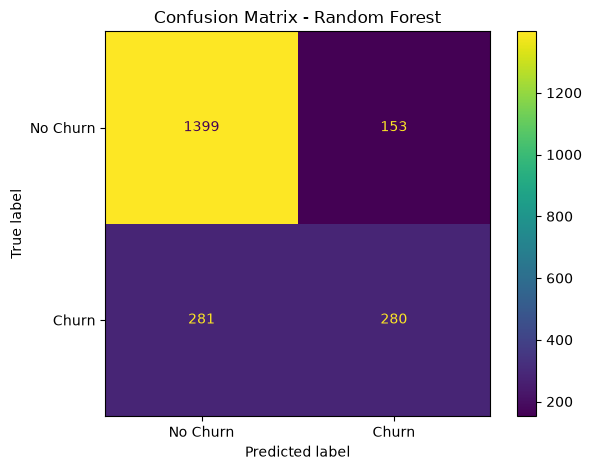

Random Forest training and evaluation completed.
Confusion Matrix PNG: ../reports/confusion_matrix_random_forest.png
Classification Report CSV: ../reports/classification_report_random_forest.csv


In [23]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

random_forest_model = train_and_evaluate_model(
    model_name="Random Forest",
    model=random_forest_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

## 6. Gradient Boosting

Gradient Boosting is an ensemble-based classification algorithm that builds models sequentially, where each new model attempts to correct the errors of the previous models.

Assignment Mapping:
- Sub-Objective 2.1 – Model Preparation
- Sub-Objective 2.2 – Model Training

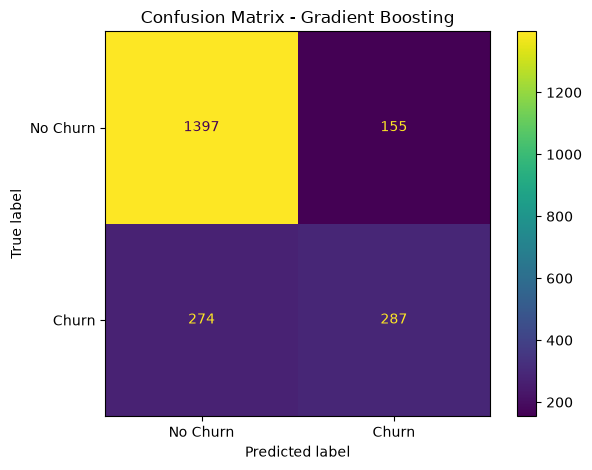

Gradient Boosting training and evaluation completed.
Confusion Matrix PNG: ../reports/confusion_matrix_gradient_boosting.png
Classification Report CSV: ../reports/classification_report_gradient_boosting.csv


In [24]:
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting_model = train_and_evaluate_model(
    model_name="Gradient Boosting",
    model=gradient_boosting_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

## 7. Model Comparison

The performance of all trained machine learning models is compared using standard classification metrics. This comparison helps identify the best-performing model for customer churn prediction.

Assignment Mapping:
- Sub-Objective 2.3 – Model Evaluation

In [25]:
# Create model comparison DataFrame
model_comparison_df = pd.DataFrame(model_results)

# Sort by F1 Score (highest first)
model_comparison_df = model_comparison_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

# Display comparison
model_comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.808803,0.666667,0.559715,0.608527
1,Gradient Boosting,0.796971,0.649321,0.511586,0.572283
2,Random Forest,0.794605,0.646651,0.499109,0.563380


In [26]:
# Save Model Comparison

model_comparison_df.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.axis("off")

table = ax.table(
    cellText=model_comparison_df.round(4).values,
    colLabels=model_comparison_df.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

plt.savefig(
    "../reports/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Model comparison artifacts saved successfully.")

model_comparison_df

Model comparison artifacts saved successfully.


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.808803,0.666667,0.559715,0.608527
1,Gradient Boosting,0.796971,0.649321,0.511586,0.572283
2,Random Forest,0.794605,0.646651,0.499109,0.563380


## 8. Best Model Selection

The best model is selected based on the F1 Score, as it balances precision and recall. This is especially important for customer churn prediction because both identifying churn customers and avoiding false alarms are relevant to business decision-making.

Assignment Mapping:
- Sub-Objective 2.3 – Model Evaluation

In [27]:
best_model_name = model_comparison_df.iloc[0]["Model"]
best_model_f1_score = model_comparison_df.iloc[0]["F1 Score"]

print("Best Model Selected:", best_model_name)
print("Best F1 Score:", round(best_model_f1_score, 4))

best_model_summary = pd.DataFrame({
    "Item": [
        "Best Model",
        "Selection Metric",
        "Best F1 Score"
    ],
    "Value": [
        best_model_name,
        "F1 Score",
        round(best_model_f1_score, 4)
    ]
})

best_model_summary.to_csv(
    "../reports/best_model_summary.csv",
    index=False
)

best_model_summary

Best Model Selected: Logistic Regression
Best F1 Score: 0.6085


,Item,Value
0,Best Model,Logistic Regression
1,Selection Metric,F1 Score
2,Best F1 Score,0.6085


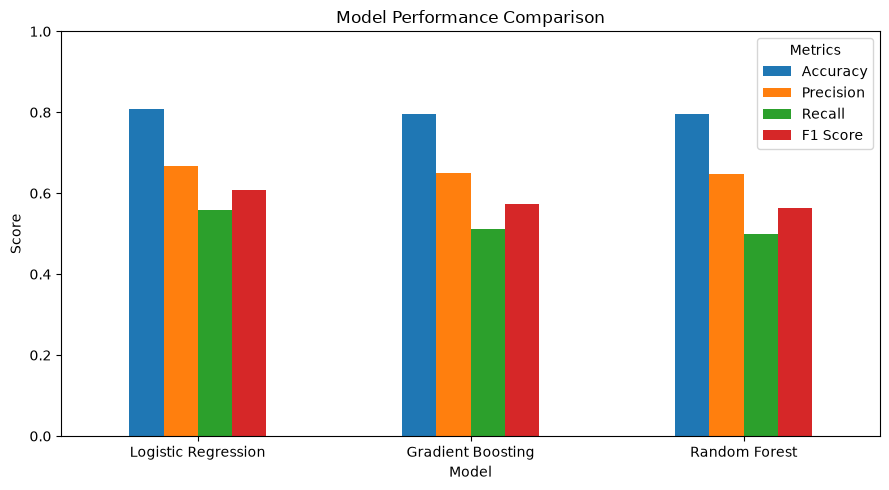

Model performance comparison plot saved successfully.
PNG : ../reports/model_performance_comparison.png


In [28]:
metrics_for_plot = ["Accuracy", "Precision", "Recall", "F1 Score"]

model_comparison_plot_df = model_comparison_df.set_index("Model")[metrics_for_plot]

ax = model_comparison_plot_df.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")

plt.tight_layout()

plt.savefig(
    "../reports/model_performance_comparison.png",
    dpi=300
)

plt.show()

print("Model performance comparison plot saved successfully.")
print("PNG : ../reports/model_performance_comparison.png")

In [29]:
os.makedirs("../models", exist_ok=True)

best_model = logistic_regression_model

best_model_path = "../models/best_customer_churn_model.pkl"

joblib.dump(best_model, best_model_path)

print("Best model saved successfully.")
print("Best Model:", best_model_name)
print("Model Path:", best_model_path)

Best model saved successfully.
Best Model: Logistic Regression
Model Path: ../models/best_customer_churn_model.pkl


## 9. MLflow Experiment Tracking

MLflow is used to track the machine learning experiment by logging model performance metrics and saving the best-performing model artifact.

Assignment Mapping:
- Sub-Objective 2.4 – MLOps

In [30]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Customer Churn Prediction")

with mlflow.start_run(run_name="Best Model - Logistic Regression"):
    mlflow.log_param("best_model", best_model_name)
    mlflow.log_param("selection_metric", "F1 Score")
    mlflow.log_param("train_test_split", "70:30")

    mlflow.log_metric("accuracy", float(model_comparison_df.loc[0, "Accuracy"]))
    mlflow.log_metric("precision", float(model_comparison_df.loc[0, "Precision"]))
    mlflow.log_metric("recall", float(model_comparison_df.loc[0, "Recall"]))
    mlflow.log_metric("f1_score", float(model_comparison_df.loc[0, "F1 Score"]))

    mlflow.sklearn.log_model(
        sk_model=best_model,
        name="best_customer_churn_model"
    )

print("MLflow experiment tracking completed successfully.")

🏃 View run Best Model - Logistic Regression at: http://127.0.0.1:5000/#/experiments/1/runs/7541f3904ef24832a5e5ecb527d923dc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
MLflow experiment tracking completed successfully.


## Conclusion

The machine learning pipeline was successfully developed for customer churn prediction. The dataset was split into training and testing sets using a 70:30 ratio, and three classification models were trained and evaluated: Logistic Regression, Random Forest, and Gradient Boosting.

Based on the model comparison results, Logistic Regression achieved the best F1 Score and was selected as the best-performing model. The selected model was saved for future API integration and deployment.

**Assignment Mapping:**
- Sub-Objective 2.1 – Model Preparation
- Sub-Objective 2.2 – Model Training
- Sub-Objective 2.3 – Model Evaluation